# Step 1: Import Libraries for Logistic Regression


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

print("Logistic Regression Libraries Imported Successfully")

Logistic Regression Libraries Imported Successfully


# Step 2: Load the Dataset

In [ ]:
df = pd.read_csv('/content/Employee Attrition.csv')

In [ ]:
df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [ ]:
df.tail()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
59593,37195,50,Female,12,Education,4414,Fair,High,Average,1,...,2,Senior,Small,35,No,No,Yes,Poor,Very High,Left
59594,6266,18,Male,4,Healthcare,8040,Fair,High,High,3,...,0,Senior,Medium,73,No,No,No,Fair,Medium,Left
59595,54887,22,Female,14,Technology,7944,Fair,High,High,0,...,2,Entry,Small,29,No,Yes,No,Good,Medium,Stayed
59596,861,23,Male,8,Education,2931,Fair,Very High,Average,0,...,0,Entry,Large,9,No,No,No,Good,Low,Left
59597,15796,56,Male,19,Technology,6660,Good,High,Average,0,...,3,Mid,Medium,81,No,No,No,Good,Low,Stayed


In [ ]:
df.shape

(59598, 24)

# Step 3: Verify Dataset

In [ ]:
# Step 2: Verify Dataset

print("Dataset Verification")
print("=" * 60)

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nAll Dataset Columns:")
print(df.columns.tolist())

Dataset Verification
Number of Rows: 59598
Number of Columns: 24

All Dataset Columns:
['Employee ID', 'Age', 'Gender', 'Years at Company', 'Job Role', 'Monthly Income', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Number of Promotions', 'Overtime', 'Distance from Home', 'Education Level', 'Marital Status', 'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition', 'Attrition']


# Step 4: Prepare Features and Target

In [ ]:
# Remove Employee ID because it is only an identifier
# Attrition is our target variable

X = df.drop(columns=['Employee ID', 'Attrition'])
y = df['Attrition']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFeature Columns:")
print(X.columns.tolist())

print("\nTarget Values:")
print(y.unique())

Feature Shape: (59598, 22)
Target Shape: (59598,)

Feature Columns:
['Age', 'Gender', 'Years at Company', 'Job Role', 'Monthly Income', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Number of Promotions', 'Overtime', 'Distance from Home', 'Education Level', 'Marital Status', 'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition']

Target Values:
['Stayed' 'Left']


# Step 5: Check Target Distribution

In [ ]:
print("Attrition Value Counts:")
print(y.value_counts())

print("\nAttrition Percentage:")
print(y.value_counts(normalize=True) * 100)

Attrition Value Counts:
Attrition
Stayed    31260
Left      28338
Name: count, dtype: int64

Attrition Percentage:
Attrition
Stayed    52.451425
Left      47.548575
Name: proportion, dtype: float64


# Step 6: Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train-Test Split Completed")
print("=" * 60)

print("Training Feature Shape:", X_train.shape)
print("Testing Feature Shape :", X_test.shape)

print("Training Target Shape :", y_train.shape)
print("Testing Target Shape  :", y_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts())

print("\nTesting Target Distribution:")
print(y_test.value_counts())

Train-Test Split Completed
Training Feature Shape: (47678, 22)
Testing Feature Shape : (11920, 22)
Training Target Shape : (47678,)
Testing Target Shape  : (11920,)

Training Target Distribution:
Attrition
Stayed    25008
Left      22670
Name: count, dtype: int64

Testing Target Distribution:
Attrition
Stayed    6252
Left      5668
Name: count, dtype: int64


# Step 7: Identify numerical and categorical features


In [ ]:
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print("Feature Type Identification")
print("=" * 60)

print("Numerical Features:")
print(numerical_features)

print("\nNumber of Numerical Features:", len(numerical_features))

print("\nCategorical Features:")
print(categorical_features)

print("\nNumber of Categorical Features:", len(categorical_features))

Feature Type Identification
Numerical Features:
['Age', 'Years at Company', 'Monthly Income', 'Number of Promotions', 'Distance from Home', 'Number of Dependents', 'Company Tenure']

Number of Numerical Features: 7

Categorical Features:
['Gender', 'Job Role', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Overtime', 'Education Level', 'Marital Status', 'Job Level', 'Company Size', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition']

Number of Categorical Features: 15


# Step 8: Create Preprocessing Pipeline


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical preprocessing
numerical_transformer = StandardScaler()

# Categorical preprocessing
categorical_transformer = OneHotEncoder(
    handle_unknown='ignore'
)

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Preprocessing Pipeline Created Successfully")
print("=" * 60)
print("Numerical Features:", len(numerical_features))
print("Categorical Features:", len(categorical_features))

Preprocessing Pipeline Created Successfully
Numerical Features: 7
Categorical Features: 15


# Step 9: Create Baseline Logistic Regression Pipeline


In [ ]:
logistic_regression_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('lr', logistic_regression_model)
    ]
)

print("Logistic Regression Pipeline Created Successfully")
print("=" * 60)
print("Model: Logistic Regression")
print("Random State: 42")
print("Max Iterations: 1000")

Logistic Regression Pipeline Created Successfully
Model: Logistic Regression
Random State: 42
Max Iterations: 1000


# Step 10: Train Baseline Logistic Regression

In [ ]:
logistic_pipeline.fit(X_train, y_train)

print("Baseline Logistic Regression Model Trained Successfully")
print("=" * 60)

Baseline Logistic Regression Model Trained Successfully


# Step 11: Generate Baseline Logistic Regression Predictions


In [ ]:
y_pred_lr = logistic_pipeline.predict(X_test)

print("Logistic Regression Predictions Generated Successfully")
print("=" * 60)
print("Number of Predictions:", len(y_pred_lr))
print("First 20 Predictions:", y_pred_lr[:20])

Logistic Regression Predictions Generated Successfully
Number of Predictions: 11920
First 20 Predictions: ['Left' 'Stayed' 'Left' 'Left' 'Left' 'Stayed' 'Left' 'Left' 'Stayed'
 'Left' 'Stayed' 'Stayed' 'Stayed' 'Stayed' 'Stayed' 'Stayed' 'Stayed'
 'Stayed' 'Left' 'Stayed']


# Step 12: Baseline Logistic Regression Performance


In [ ]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, pos_label='Left')
recall_lr = recall_score(y_test, y_pred_lr, pos_label='Left')
f1_lr = f1_score(y_test, y_pred_lr, pos_label='Left')

print("Baseline Logistic Regression Performance")
print("=" * 60)
print(f"Accuracy : {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1 Score : {f1_lr:.4f}")

Baseline Logistic Regression Performance
Accuracy : 0.7499
Precision: 0.7394
Recall   : 0.7320
F1 Score : 0.7357


# Step 13: Baseline Logistic Regression Confusion Matrix


In [ ]:
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr,
    labels=['Stayed', 'Left']
)

print("Baseline Logistic Regression Confusion Matrix")
print("=" * 60)
print(cm_lr)
print("\nTotal samples in confusion matrix:", cm_lr.sum())

Baseline Logistic Regression Confusion Matrix
[[4790 1462]
 [1519 4149]]

Total samples in confusion matrix: 11920


# Step 14: Baseline Logistic Regression Classification Report


In [ ]:
print("Classification Report - Baseline Logistic Regression")
print("=" * 60)

print(
    classification_report(y_test, y_pred_lr,
        labels=['Stayed', 'Left'],
        digits=4
    )
)

Classification Report - Baseline Logistic Regression
              precision    recall  f1-score   support

      Stayed     0.7592    0.7662    0.7627      6252
        Left     0.7394    0.7320    0.7357      5668

    accuracy                         0.7499     11920
   macro avg     0.7493    0.7491    0.7492     11920
weighted avg     0.7498    0.7499    0.7499     11920



# Step 15: Baseline Logistic Regression ROC-AUC


In [ ]:
# Convert target to binary:
# Left = 1
# Stayed = 0

y_test_binary = (y_test == 'Left').astype(int)

# Get probability of Left
y_proba_lr = logistic_pipeline.predict_proba(X_test)

left_index = list(logistic_pipeline.classes_).index('Left')

y_proba_left = y_proba_lr[:, left_index]

# Calculate ROC-AUC
roc_auc_lr = roc_auc_score(
    y_test_binary,
    y_proba_left
)

print("Baseline Logistic Regression ROC-AUC")
print("=" * 60)
print(f"ROC-AUC : {roc_auc_lr:.4f}")

Baseline Logistic Regression ROC-AUC
ROC-AUC : 0.8396


# Step 16: Baseline Logistic Regression ROC Curve


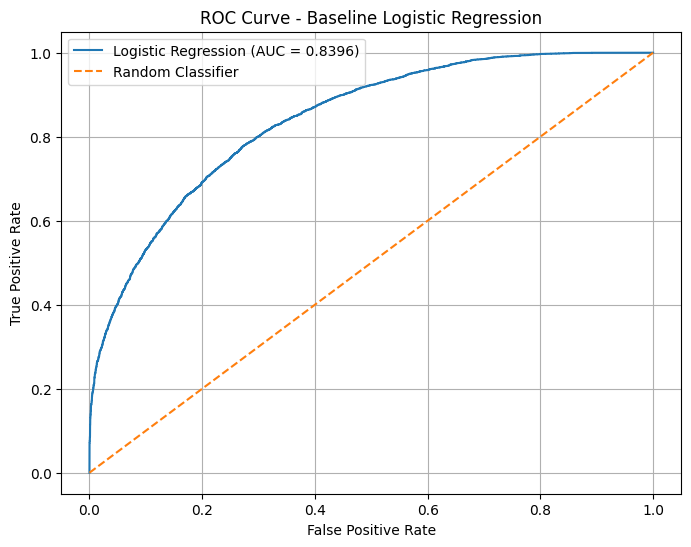

In [ ]:
fpr_lr, tpr_lr, thresholds_lr = roc_curve(
    y_test_binary,
    y_proba_left
)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr_lr,
    tpr_lr,
    label=f'Logistic Regression (AUC = {roc_auc_lr:.4f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Baseline Logistic Regression')
plt.legend()
plt.grid()
plt.show()

# Step 14 — Logistic Regression Hyperparameter Tuning

We'll tune the model using GridSearchCV and optimize for F1 score of the Left class.

In [ ]:
from sklearn.metrics import make_scorer, f1_score

f1_left_scorer = make_scorer(
    f1_score,
    pos_label='Left'
)

param_grid_lr = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__solver': ['liblinear', 'lbfgs'],
    'lr__class_weight': [None, 'balanced']
}

print("Logistic Regression Parameter Grid")
print("=" * 60)
print(param_grid_lr)

Logistic Regression Parameter Grid
{'lr__C': [0.01, 0.1, 1, 10, 100], 'lr__solver': ['liblinear', 'lbfgs'], 'lr__class_weight': [None, 'balanced']}


In [ ]:
from sklearn.model_selection import GridSearchCV

grid_lr = GridSearchCV(
    estimator = logistic_pipeline,
    param_grid = param_grid_lr,
    cv = 5,
    scoring = f1_left_scorer,
    n_jobs = -1,
    verbose = 1
)

grid_lr.fit(X_train, y_train)

print("Logistic Regression Hyperparameter Tuning Completed")
print("=" * 60)

print("Best Parameters:")
print(grid_lr.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(f"{grid_lr.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Logistic Regression Hyperparameter Tuning Completed
Best Parameters:
{'lr__C': 1, 'lr__class_weight': 'balanced', 'lr__solver': 'liblinear'}

Best Cross-Validation F1 Score:
0.7431


# Step 15: Train the best Logistic Regression model

In [ ]:
# Get the best Logistic Regression model
best_lr = grid_lr.best_estimator_

# Train the best model on the training data
best_lr.fit(X_train, y_train)

print("Tuned Logistic Regression Model Trained Successfully")
print("=" * 60)
print("Best Parameters:")
print(grid_lr.best_params_)

Tuned Logistic Regression Model Trained Successfully
Best Parameters:
{'lr__C': 1, 'lr__class_weight': 'balanced', 'lr__solver': 'liblinear'}


# Step 16: Generate predictions using tuned Logistic Regression

In [ ]:
y_pred_lr_tuned = best_lr.predict(X_test)

print("Tuned Logistic Regression Predictions Generated Successfully")
print("=" * 60)
print("Number of Predictions:", len(y_pred_lr_tuned))
print("First 20 Predictions:", y_pred_lr_tuned[:20])

Tuned Logistic Regression Predictions Generated Successfully
Number of Predictions: 11920
First 20 Predictions: ['Left' 'Stayed' 'Left' 'Left' 'Left' 'Stayed' 'Left' 'Left' 'Stayed'
 'Left' 'Stayed' 'Stayed' 'Stayed' 'Stayed' 'Left' 'Stayed' 'Stayed'
 'Stayed' 'Left' 'Left']


# Step 17: Tuned Logistic Regression Performance


In [ ]:
accuracy_lr_tuned = accuracy_score(y_test, y_pred_lr_tuned)
precision_lr_tuned = precision_score(y_test, y_pred_lr_tuned, pos_label='Left')
recall_lr_tuned = recall_score(y_test, y_pred_lr_tuned, pos_label='Left')
f1_lr_tuned = f1_score(y_test, y_pred_lr_tuned, pos_label='Left')

print("Tuned Logistic Regression Performance")
print("=" * 60)
print(f"Accuracy : {accuracy_lr_tuned:.4f}")
print(f"Precision: {precision_lr_tuned:.4f}")
print(f"Recall   : {recall_lr_tuned:.4f}")
print(f"F1 Score : {f1_lr_tuned:.4f}")

Tuned Logistic Regression Performance
Accuracy : 0.7500
Precision: 0.7301
Recall   : 0.7523
F1 Score : 0.7410


# Step 18: Tuned Logistic Regression Confusion Matrix


In [ ]:
cm_lr_tuned = confusion_matrix(
    y_test,
    y_pred_lr_tuned,
    labels=['Stayed', 'Left']
)

print("Tuned Logistic Regression Confusion Matrix")
print("=" * 60)
print(cm_lr_tuned)
print("\nTotal samples in confusion matrix:", cm_lr_tuned.sum())

Tuned Logistic Regression Confusion Matrix
[[4676 1576]
 [1404 4264]]

Total samples in confusion matrix: 11920


# Step 19: Tuned Logistic Regression Classification Report


In [ ]:
print("Classification Report - Tuned Logistic Regression")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_lr_tuned,
        labels=['Stayed', 'Left'],
        digits=4
    )
)

Classification Report - Tuned Logistic Regression
              precision    recall  f1-score   support

      Stayed     0.7691    0.7479    0.7584      6252
        Left     0.7301    0.7523    0.7410      5668

    accuracy                         0.7500     11920
   macro avg     0.7496    0.7501    0.7497     11920
weighted avg     0.7506    0.7500    0.7501     11920



# Step 20: Tuned Logistic Regression ROC-AUC


In [ ]:
y_proba_lr_tuned = best_lr.predict_proba(X_test)

# Get probability column for 'Left'
left_index_tuned = list(best_lr.classes_).index('Left')

y_proba_left_tuned = y_proba_lr_tuned[:, left_index_tuned]

# Convert actual target to binary
y_test_binary = (y_test == 'Left').astype(int)

# Calculate ROC-AUC
roc_auc_lr_tuned = roc_auc_score(
    y_test_binary,
    y_proba_left_tuned
)

print("Tuned Logistic Regression ROC-AUC")
print("=" * 60)
print(f"ROC-AUC : {roc_auc_lr_tuned:.4f}")

Tuned Logistic Regression ROC-AUC
ROC-AUC : 0.8396


# Step 21: Tuned Logistic Regression ROC Curve


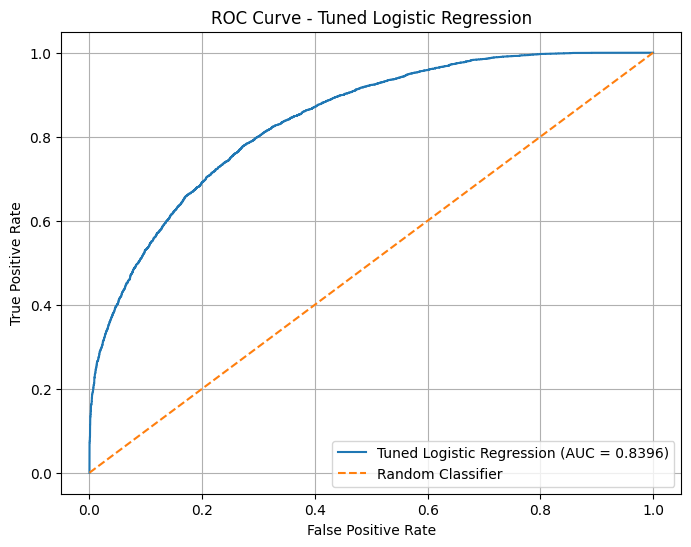

In [ ]:
fpr_lr_tuned, tpr_lr_tuned, thresholds_lr_tuned = roc_curve(
    y_test_binary,
    y_proba_left_tuned
)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr_lr_tuned,
    tpr_lr_tuned,
    label=f'Tuned Logistic Regression (AUC = {roc_auc_lr_tuned:.4f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned Logistic Regression')
plt.legend()
plt.grid()
plt.show()

# Step 22: Logistic Regression Feature Importance

- coef_

The coefficient tells us the direction and strength of the relationship between a feature and the predicted class.

Because your model uses a preprocessing pipeline with numerical scaling + categorical One-Hot Encoding, we need to correctly extract the transformed feature names.

In [ ]:
import pandas as pd
import numpy as np

print("Logistic Regression Feature Importance")
print("=" * 60)

# Get the trained Logistic Regression model
lr_model = grid_lr.best_estimator_.named_steps['lr']

# Get the preprocessing pipeline
preprocessor = grid_lr.best_estimator_.named_steps['preprocessor']

# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

# Get Logistic Regression coefficients
coefficients = lr_model.coef_[0]

# Create DataFrame
lr_feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Absolute coefficient for measuring strength
lr_feature_importance['Absolute_Coefficient'] = (
    lr_feature_importance['Coefficient'].abs()
)

# Sort by absolute coefficient
lr_feature_importance = lr_feature_importance.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

# Display top 15 features
print("\nTop 15 Logistic Regression Features:")
print("=" * 60)

print(
    lr_feature_importance[
        ['Feature', 'Coefficient']
    ].head(15).to_string(index=False)
)

Logistic Regression Feature Importance

Top 15 Logistic Regression Features:
                         Feature  Coefficient
           cat__Job Level_Senior     1.457497
        cat__Education Level_PhD     1.287828
            cat__Job Level_Entry    -1.166517
      cat__Marital Status_Single    -1.082868
            cat__Remote Work_Yes     0.957038
             cat__Remote Work_No    -0.826985
cat__Work-Life Balance_Excellent     0.823164
     cat__Marital Status_Married     0.736356
     cat__Work-Life Balance_Poor    -0.701291
     cat__Work-Life Balance_Good     0.526222
     cat__Work-Life Balance_Fair    -0.518042
    cat__Marital Status_Divorced     0.476565
    cat__Company Reputation_Poor    -0.446720
    cat__Company Reputation_Good     0.396281
                cat__Gender_Male     0.390694


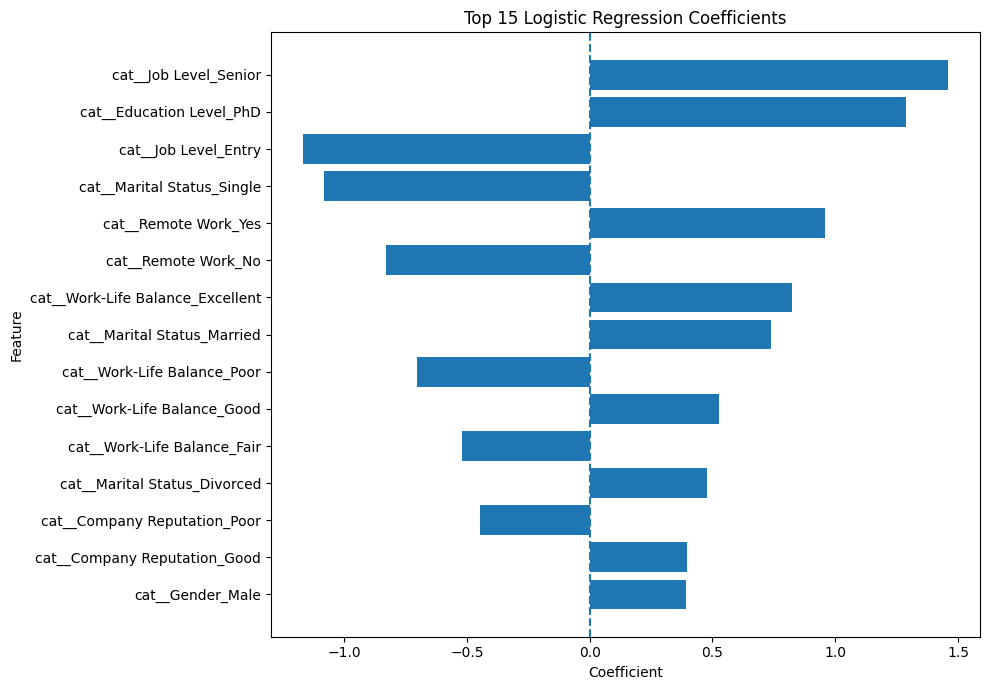

In [ ]:
import matplotlib.pyplot as plt

# Get top 15 features
top_features = lr_feature_importance.head(15).sort_values(
    by='Absolute_Coefficient',
    ascending=True
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_features['Feature'],
    top_features['Coefficient']
)

plt.axvline(x=0, linestyle='--')
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top 15 Logistic Regression Coefficients")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate Baseline Logistic Regression metrics
accuracy_lr_baseline = accuracy_score(y_test, y_pred_lr)

precision_lr_baseline = precision_score(
    y_test,
    y_pred_lr,
    pos_label='Left'
)

recall_lr_baseline = recall_score(
    y_test,
    y_pred_lr,
    pos_label='Left'
)

f1_lr_baseline = f1_score(
    y_test,
    y_pred_lr,
    pos_label='Left'
)

print("Baseline Logistic Regression Performance")
print("=" * 60)
print(f"Accuracy : {accuracy_lr_baseline:.4f}")
print(f"Precision: {precision_lr_baseline:.4f}")
print(f"Recall   : {recall_lr_baseline:.4f}")
print(f"F1 Score : {f1_lr_baseline:.4f}")

Baseline Logistic Regression Performance
Accuracy : 0.7499
Precision: 0.7394
Recall   : 0.7320
F1 Score : 0.7357


In [ ]:
from sklearn.metrics import roc_auc_score

# Generate baseline probability predictions
y_prob_lr_baseline = logistic_pipeline.predict_proba(X_test)[:, 1]

# Calculate baseline ROC-AUC
roc_auc_lr_baseline = roc_auc_score(
    y_test,
    y_prob_lr_baseline
)

print("Baseline Logistic Regression ROC-AUC")
print("=" * 60)
print(f"ROC-AUC : {roc_auc_lr_baseline:.4f}")

Baseline Logistic Regression ROC-AUC
ROC-AUC : 0.8396


# Step 23: Baseline vs Tuned Logistic Regression

In [ ]:
import pandas as pd

comparison_lr = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision (Left)',
        'Recall (Left)',
        'F1 Score (Left)',
        'ROC-AUC'
    ],
    'Baseline': [
        accuracy_lr_baseline,
        precision_lr_baseline,
        recall_lr_baseline,
        f1_lr_baseline,
        roc_auc_lr_baseline
    ],
    'Tuned': [
        accuracy_lr_tuned,
        precision_lr_tuned,
        recall_lr_tuned,
        f1_lr_tuned,
        roc_auc_lr_tuned
    ]
})

print("Baseline vs Tuned Logistic Regression")
print("=" * 70)
print(comparison_lr.to_string(index=False))

Baseline vs Tuned Logistic Regression
          Metric  Baseline    Tuned
        Accuracy  0.749916 0.750000
Precision (Left)  0.739440 0.730137
   Recall (Left)  0.732004 0.752294
 F1 Score (Left)  0.735704 0.741050
         ROC-AUC  0.839615 0.839612


## Conclusion:
Logistic Regression achieved a baseline ROC-AUC of approximately 0.84 and an F1 score of 0.736 for the Left class. After hyperparameter tuning with class balancing, the F1 score improved to 0.741 and recall increased from 0.732 to 0.752, while ROC-AUC remained approximately 0.84. Therefore, tuning improved the model's ability to identify employees who left, with a small trade-off in precision.

# Step 24: Save the Tuned Logistic Regression Model

In [ ]:
import joblib

# Save the complete tuned Logistic Regression pipeline
joblib.dump(
    grid_lr.best_estimator_,
    'Employee_Attrition_Logistic_Regression_Model.pkl'
)

print("Logistic Regression Model Saved Successfully")
print("=" * 60)
print("File Name: Employee_Attrition_Logistic_Regression_Model.pkl")

Logistic Regression Model Saved Successfully
File Name: Employee_Attrition_Logistic_Regression_Model.pkl


# Step 25: Load the Saved Model

In [ ]:
import joblib

loaded_lr_model = joblib.load(
    'Employee_Attrition_Logistic_Regression_Model.pkl'
)

print("Logistic Regression Model Loaded Successfully")

Logistic Regression Model Loaded Successfully


# Step 26: Verify the Loaded Model

In [ ]:
# Predictions using the loaded model
y_pred_loaded_lr = loaded_lr_model.predict(X_test)

print("Loaded Logistic Regression Model Prediction")
print("=" * 60)
print("First 20 Predictions:")
print(y_pred_loaded_lr[:20])

Loaded Logistic Regression Model Prediction
First 20 Predictions:
['Left' 'Stayed' 'Left' 'Left' 'Left' 'Stayed' 'Left' 'Left' 'Stayed'
 'Left' 'Stayed' 'Stayed' 'Stayed' 'Stayed' 'Left' 'Stayed' 'Stayed'
 'Stayed' 'Left' 'Left']


# Step 27: Generate predictions from the loaded model

In [ ]:
y_pred_loaded_lr = loaded_lr_model.predict(X_test)

print("Loaded Logistic Regression Model Verification")
print("=" * 60)
print("Number of Predictions:", len(y_pred_loaded_lr))
print("First 20 Predictions:")
print(y_pred_loaded_lr[:20])

Loaded Logistic Regression Model Verification
Number of Predictions: 11920
First 20 Predictions:
['Left' 'Stayed' 'Left' 'Left' 'Left' 'Stayed' 'Left' 'Left' 'Stayed'
 'Left' 'Stayed' 'Stayed' 'Stayed' 'Stayed' 'Left' 'Stayed' 'Stayed'
 'Stayed' 'Left' 'Left']


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_loaded_lr = accuracy_score(y_test, y_pred_loaded_lr)

precision_loaded_lr = precision_score(
    y_test,
    y_pred_loaded_lr,
    pos_label='Left'
)

recall_loaded_lr = recall_score(
    y_test,
    y_pred_loaded_lr,
    pos_label='Left'
)

f1_loaded_lr = f1_score(
    y_test,
    y_pred_loaded_lr,
    pos_label='Left'
)

print("Loaded Logistic Regression Performance")
print("=" * 60)
print(f"Accuracy : {accuracy_loaded_lr:.4f}")
print(f"Precision: {precision_loaded_lr:.4f}")
print(f"Recall   : {recall_loaded_lr:.4f}")
print(f"F1 Score : {f1_loaded_lr:.4f}")

Loaded Logistic Regression Performance
Accuracy : 0.7500
Precision: 0.7301
Recall   : 0.7523
F1 Score : 0.7410


# Step 28: New Employee Prediction

In [ ]:
new_employee = pd.DataFrame({
    'Age': [30],
    'Gender': ['Male'],
    'Years at Company': [5],
    'Job Role': ['Technology'],
    'Monthly Income': [6000],
    'Work-Life Balance': ['Good'],
    'Job Satisfaction': ['High'],
    'Performance Rating': ['High'],
    'Number of Promotions': [1],
    'Overtime': ['No'],
    'Distance from Home': [10],
    'Education Level': ['Bachelor'],
    'Marital Status': ['Married'],
    'Number of Dependents': [2],
    'Job Level': ['Mid'],
    'Company Size': ['Medium'],
    'Company Tenure': [5],
    'Remote Work': ['Yes'],
    'Leadership Opportunities': ['Yes'],
    'Innovation Opportunities': ['Yes'],
    'Company Reputation': ['Good'],
    'Employee Recognition': ['High']
})

print("New Employee Data")
print("=" * 60)
print(new_employee)

New Employee Data
   Age Gender  Years at Company    Job Role  Monthly Income Work-Life Balance  \
0   30   Male                 5  Technology            6000              Good   

  Job Satisfaction Performance Rating  Number of Promotions Overtime  ...  \
0             High               High                     1       No  ...   

   Marital Status Number of Dependents Job Level  Company Size Company Tenure  \
0         Married                    2       Mid        Medium              5   

  Remote Work  Leadership Opportunities Innovation Opportunities  \
0         Yes                       Yes                      Yes   

  Company Reputation Employee Recognition  
0               Good                 High  

[1 rows x 22 columns]


In [ ]:
# New Employee Attrition Prediction

new_prediction = loaded_lr_model.predict(new_employee)

print("New Employee Attrition Prediction")
print("=" * 60)
print("Prediction:", new_prediction[0])

New Employee Attrition Prediction
Prediction: Stayed


In [ ]:
# Prediction Probabilities

new_probability = loaded_lr_model.predict_proba(new_employee)

classes = loaded_lr_model.classes_

print("Detailed Prediction Probabilities")
print("=" * 60)

for class_name, probability in zip(classes, new_probability[0]):
    print(f"{class_name}: {probability:.6f}")
    print(f"{class_name}: {probability * 100:.2f}%")

Detailed Prediction Probabilities
Left: 0.011248
Left: 1.12%
Stayed: 0.988752
Stayed: 98.88%


The Logistic Regression model predicts Stayed with a probability of 98.88% for this input.